In [29]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,
                        n_clusters_per_class=1,class_sep=10,hypercube=False,random_state=41)

Text(0.5, 1.0, 'Synthetic Classification Dataset')

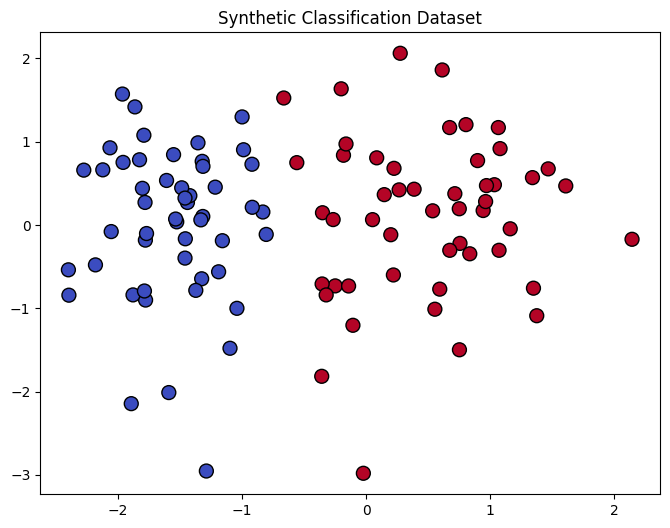

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Synthetic Classification Dataset')

/tmp/ipykernel_105865/2764611860.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


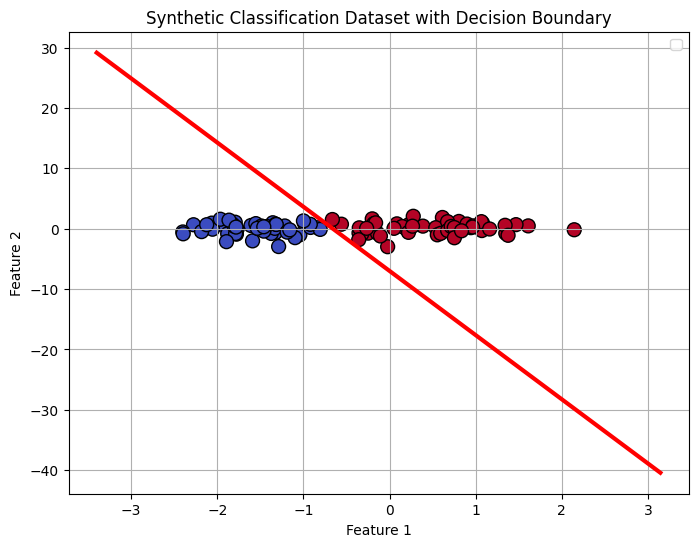

In [63]:

# Step activation function
def step(x):
    return 1 if x >= 0 else 0

# Perceptron training
def train(X, y):
    epochs = 1000
    lr = 0.1
    X = np.insert(X, 0, 1, axis=1)  # Insert bias term
    weights = np.zeros(X.shape[1])
    
    for epoch in range(epochs):
        j = np.random.randint(0, X.shape[0])
        y_hat = step(np.dot(X[j], weights))
        weights += lr * (y[j] - y_hat) * X[j]
        
    return weights

# Train the perceptron
weights = train(X, y)

# Plot decision boundary
x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
eps = 1e-6
denom = weights[2] if abs(weights[2]) > eps else eps
y_vals = -(weights[0] + weights[1] * x_vals) / denom

# Plot
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=100)
plt.plot(x_vals, y_vals, color='red', linewidth=3)
plt.title('Synthetic Classification Dataset with Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.legend()
plt.show()
